## Synch - Kuramoto order parameter (sinusoids)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.animation import FuncAnimation
%matplotlib inline
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.io import loadmat
import scipy.io as sio
from scipy.signal import hilbert
import os
from os.path import isfile,isdir,join
from os import listdir

### Data generation

In [2]:
def get_dataframe(ph0=0, frq=1, pers=1, delay=0, iterations=1000):
    t = np.linspace(0, 2*np.pi*pers, iterations)
    x = np.sin((t-delay)+ph0)*np.cos(frq*(t-delay)+ph0)
    return pd.DataFrame({'x': x})

In [3]:
df1 = get_dataframe(frq=2, ph0=0, pers=10, delay=0, iterations=1000)

In [4]:
df2 = get_dataframe(frq=2, ph0=0, pers=10, delay=3, iterations=1000)

In [5]:
#df = pd.read_parquet ('data/datos.pqt')

In [6]:
df1.shape

(1000, 1)

In [7]:
df2.shape

(1000, 1)

In [8]:
pd.options.display.float_format = '{:.8g}'.format

In [9]:
df1.describe()

,x
count,1000
mean,-1.7763568e-17
std,0.5
min,-0.99999382
25%,-0.25839702
50%,-1.2246468e-15
75%,0.25839702
max,0.99999382


In [10]:
df2.describe()

,x
count,1000
mean,-0.00013549924
std,0.50001836
min,-0.99999318
25%,-0.25840986
50%,-0.00057290461
75%,0.25838416
max,0.99999443


In [11]:
varA = df1['x'].rolling(1).mean()
varA = varA.values

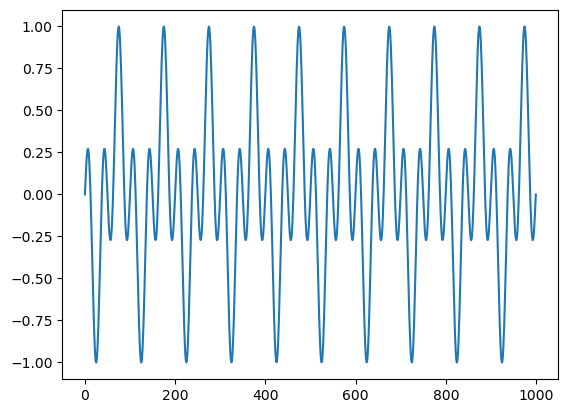

In [12]:
plt.plot(varA)

In [13]:
varB = df2['x'].rolling(1).mean()
varB = varB.values

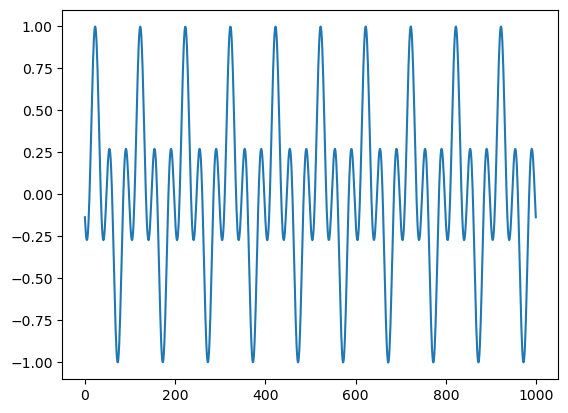

In [14]:
plt.plot(varB)

### Hilbert transforms

Analytic signal:
$\zeta(t)=s(t)+i s_H(t)=A e^{i\phi(t)}$,

where:
- $A(t)$: instantaneous amplitude of the signal $s(t)$
- $\phi(t)$: instantaneous phase of the signal $s(t)$
- $s_H(t)=\frac{1}{\pi} P.V. \int_{-\infty}^{\infty} \frac{s(\tau)}{t-\tau} d\tau$: Hilbert transform of the signal $s(t)$

In [15]:
hil_evol_A = hilbert(varA)

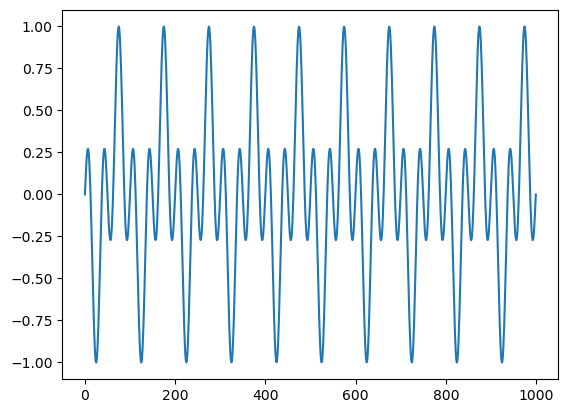

In [16]:
plt.plot(hil_evol_A.real)

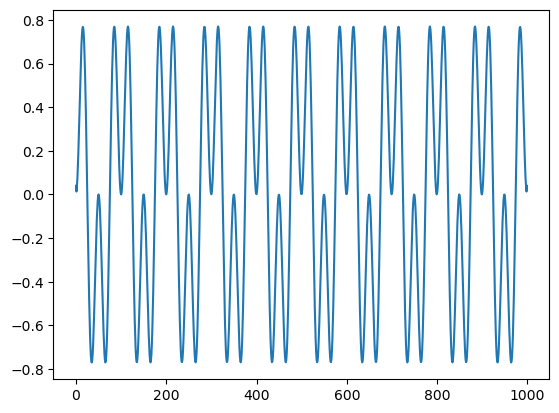

In [17]:
plt.plot(hil_evol_A.imag)

In [18]:
hil_evol_B = hilbert(varB)

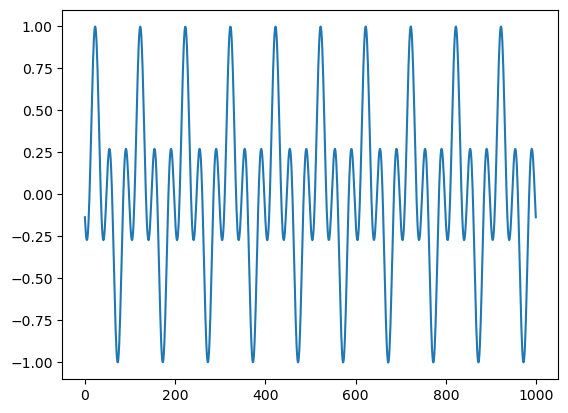

In [19]:
plt.plot(hil_evol_B.real)

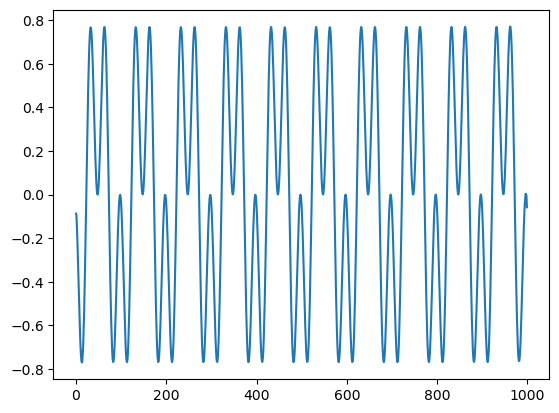

In [20]:
plt.plot(hil_evol_B.imag)

### Phases

In [21]:
ph_evol_A = np.arctan2(hil_evol_A.imag, hil_evol_A.real)

In [22]:
ph_evol_B = np.arctan2(hil_evol_B.imag, hil_evol_B.real)

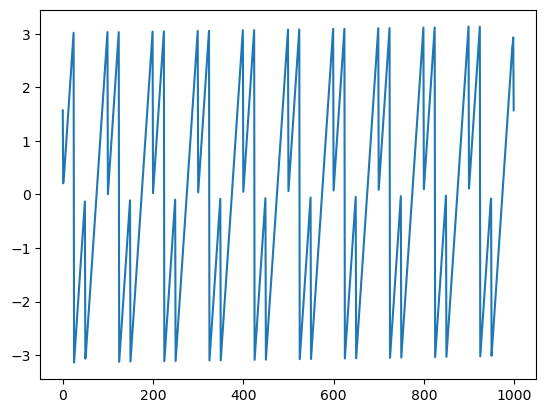

In [23]:
plt.plot(ph_evol_A)

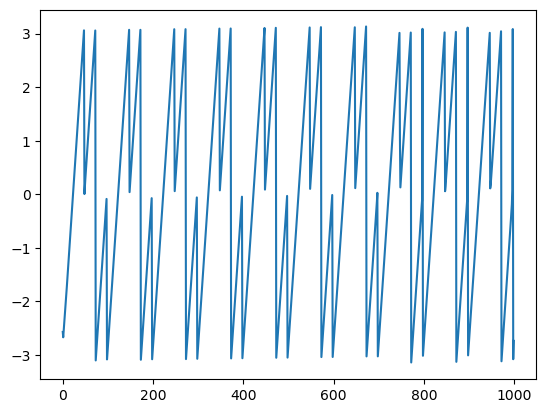

In [24]:
plt.plot(ph_evol_B)

### Kuramoto order parameter

In [25]:
R_A = np.exp(1j*ph_evol_A)
R_A = np.abs(R_A)

In [26]:
R_B = np.exp(1j*ph_evol_B)
R_B = np.abs(R_B)

In [27]:
R = (np.exp(1j*ph_evol_A)+np.exp(1j*ph_evol_B))/2
R = np.abs(R)

Text(0.5, 1.0, 'Kuramoto order parameter')

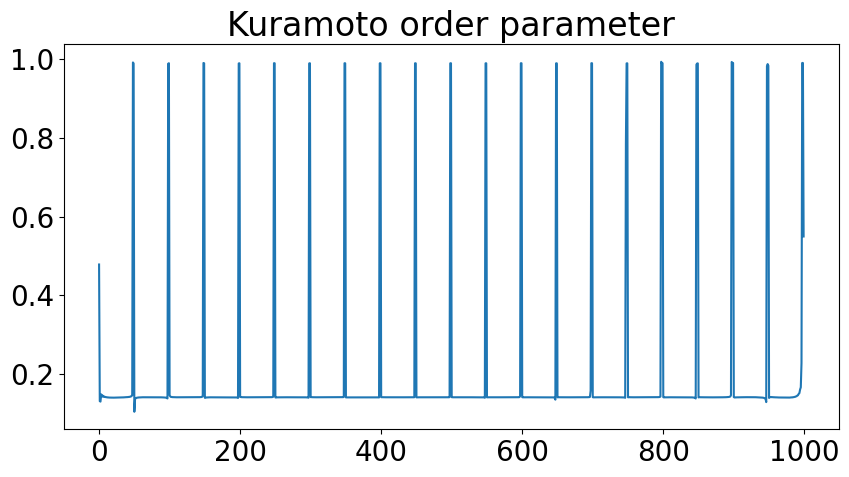

In [28]:
fig,ax = plt.subplots(figsize=(10,5))
plt.plot(R)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Kuramoto order parameter', fontsize=24)

### State space diagrams and phases plots

Text(0.5, 1.0, 'State space for phases')

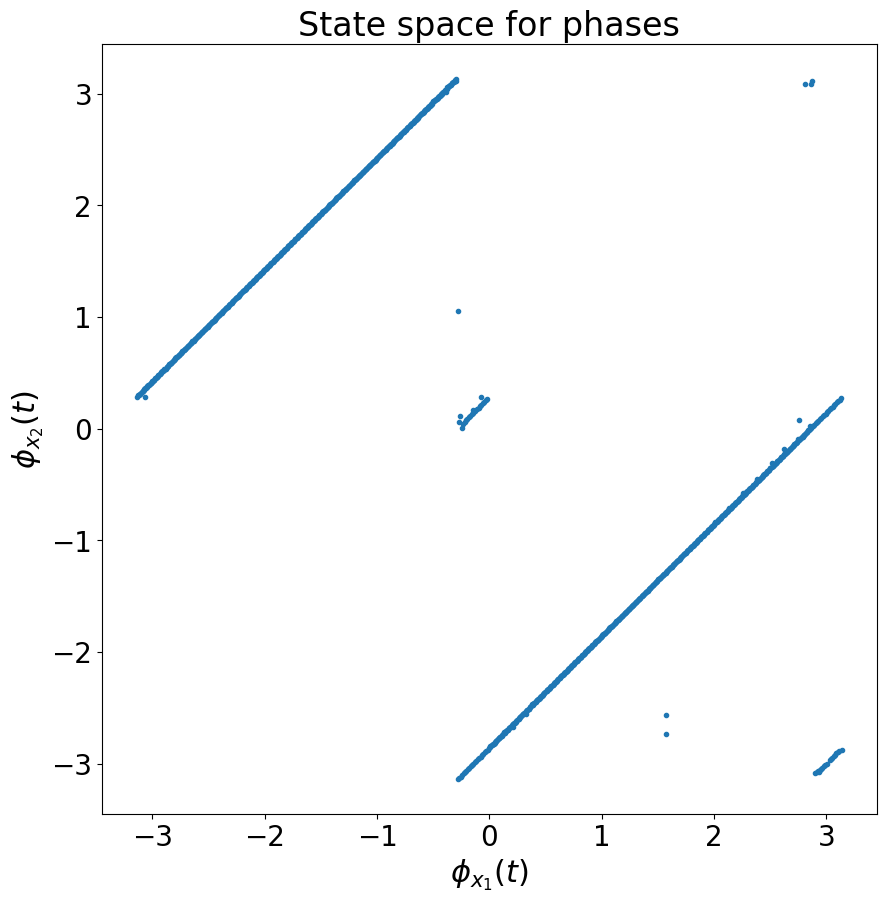

In [29]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(ph_evol_A,ph_evol_B,'.')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\phi_{x_1} (t)$', fontsize=22)
plt.ylabel('$\phi_{x_2} (t)$', fontsize=22)
plt.title('State space for phases', fontsize=24)

In [30]:
theta = np.linspace(-np.pi, np.pi, 100)

Text(0.5, 1.0, 'Phases')

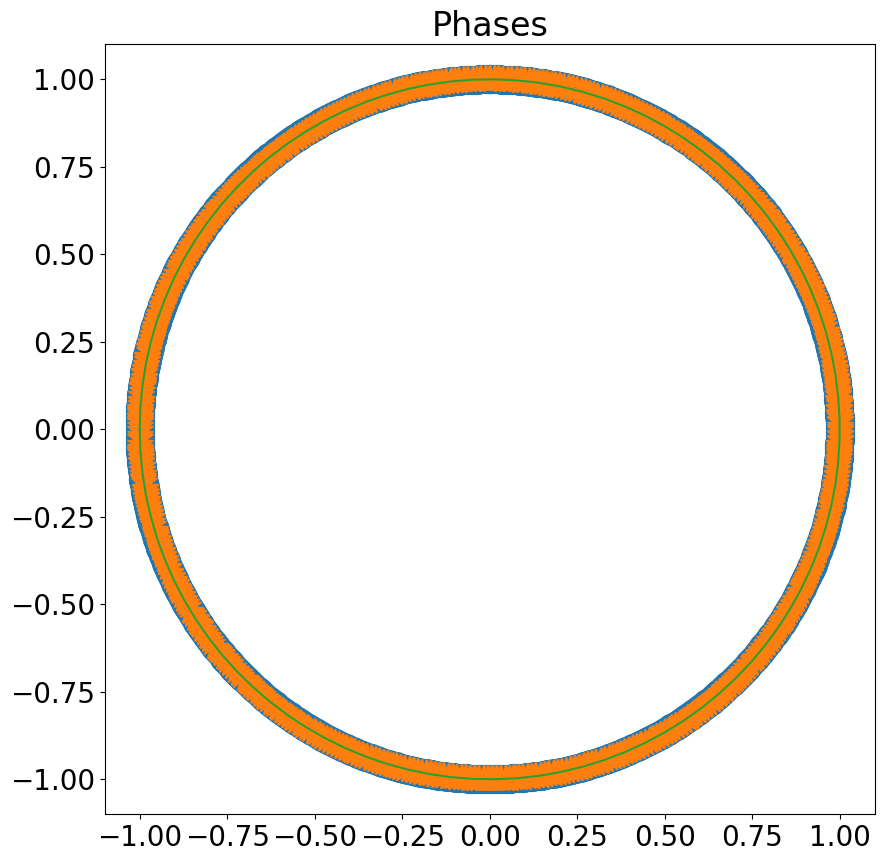

In [31]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(np.cos(ph_evol_A),np.sin(ph_evol_A),'o',np.cos(ph_evol_B),np.sin(ph_evol_B),'*',np.cos(theta), np.sin(theta), '-', markersize=20)
ax.set_aspect(1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phases', fontsize=24)
#plt.savefig('figures/phases.pdf')


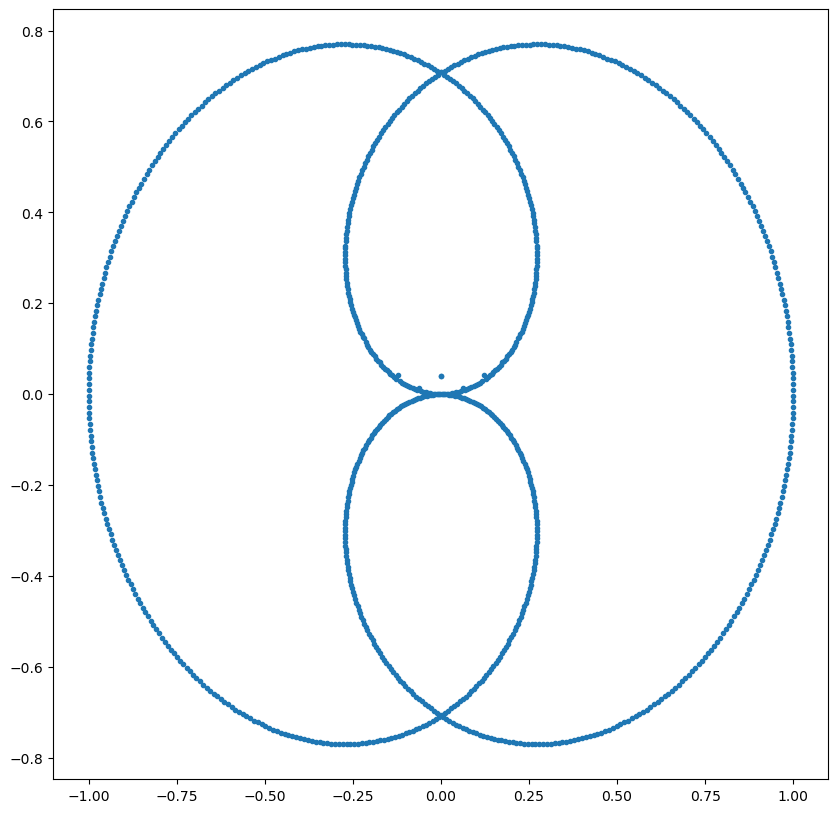

In [32]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_A.real,hil_evol_A.imag,'.')
#ax.set_aspect(1)

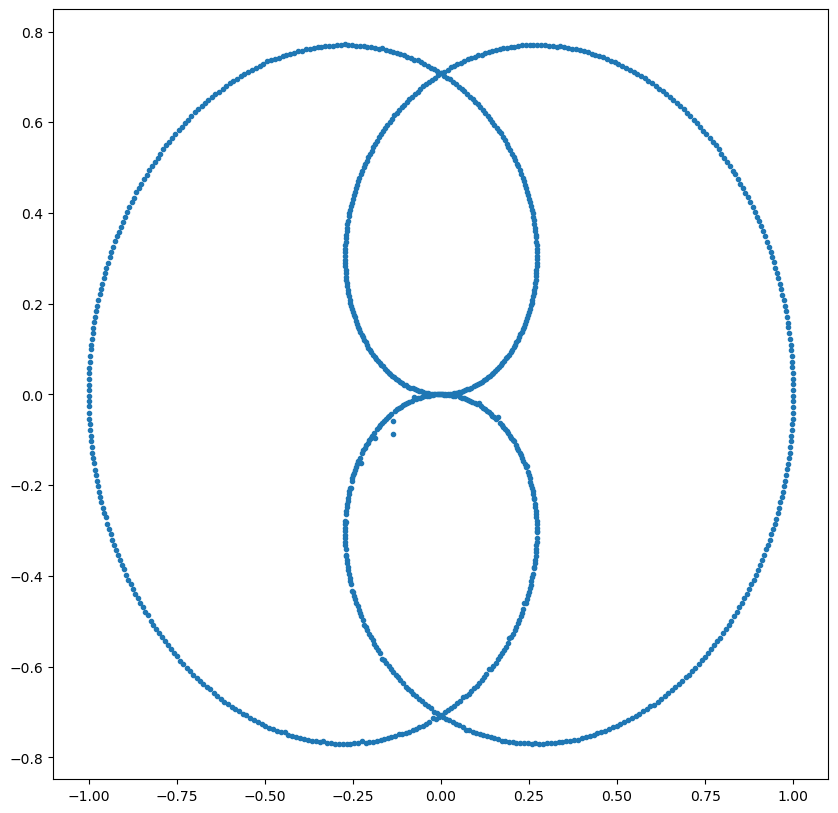

In [33]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_B.real,hil_evol_B.imag,'.')
#ax.set_aspect(1)

In [34]:
phA_B=np.arctan2(hil_evol_A.imag*hil_evol_B.real-hil_evol_A.real*hil_evol_B.imag, hil_evol_A.real*hil_evol_B.real+hil_evol_A.imag*hil_evol_B.imag)

Text(0.5, 1.0, 'Phase difference')

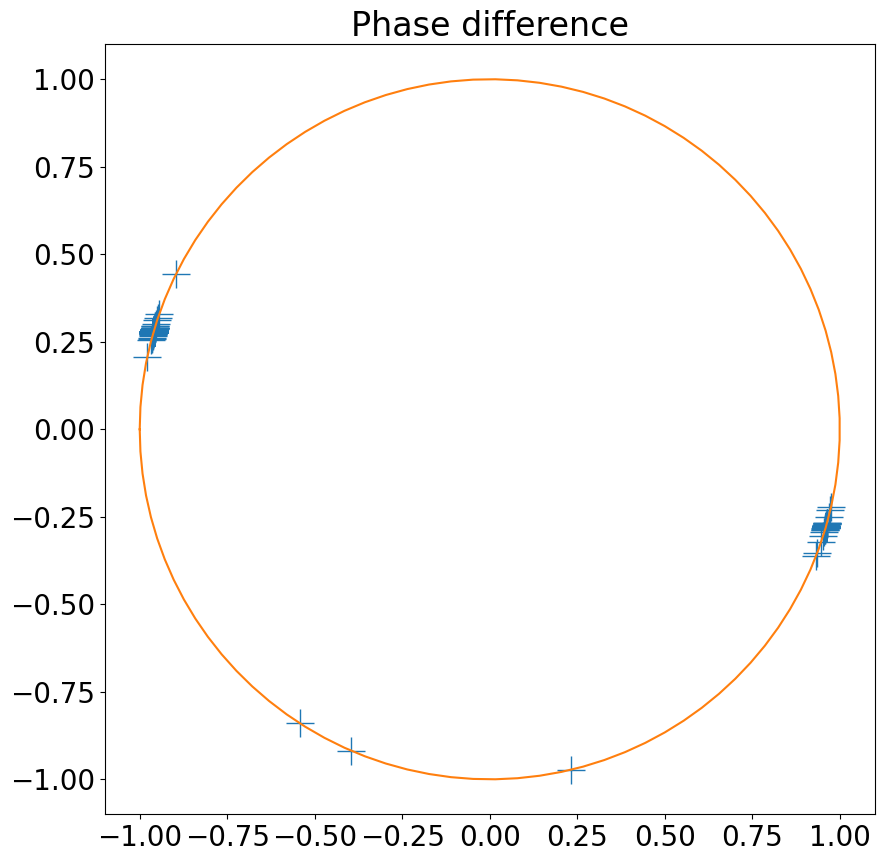

In [35]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(np.cos(phA_B),np.sin(phA_B),'+',np.cos(theta), np.sin(theta), '-', markersize=20)
ax.set_aspect(1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phase difference', fontsize=24)
#plt.savefig('figures/phases_diff_circ.pdf')

Text(0.5, 1.0, 'Phase difference')

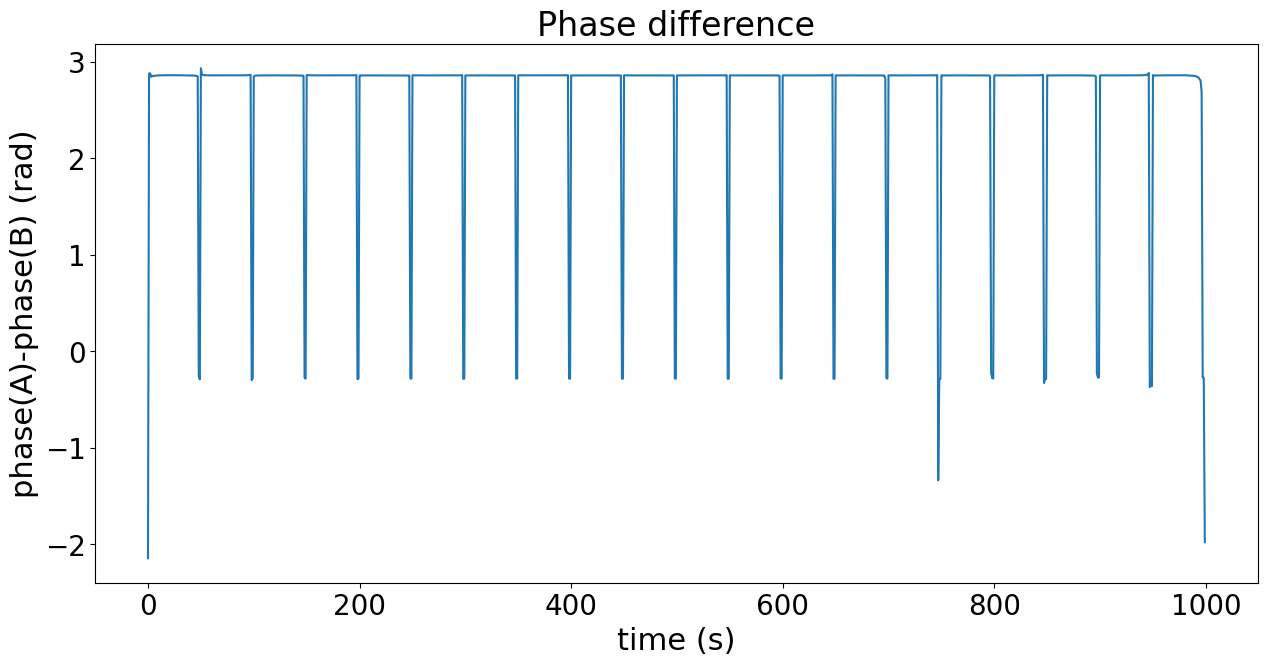

In [36]:
fig,ax = plt.subplots(figsize=(15,7))
plt.plot(df1.index,(phA_B), '-', markersize=20)
#plt.ylim([-0.2,0.2])
plt.xlabel('time (s)', fontsize=22)
plt.ylabel('phase(A)-phase(B) (rad)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phase difference', fontsize=24)
#plt.savefig('figures/phases_diff.pdf')

### Recurrence plot


In [41]:
def recurrence_plot(data, threshold=0.1):
    """
    Recurrence plot from a time series
    
    :param data: Time series data
    :param threshold: Threshold to determine recurrence
    :return: Recurrence plot
    """
    # Calculate the distance matrix
    N = len(data)
    distance_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            distance_matrix[i,j] = np.abs(data[i] - data[j])
            
    # Create the recurrence plot
    recurrence_plot = np.where(distance_matrix <= threshold, 1, 0)
    
    return recurrence_plot

<function matplotlib.pyplot.show(close=None, block=None)>

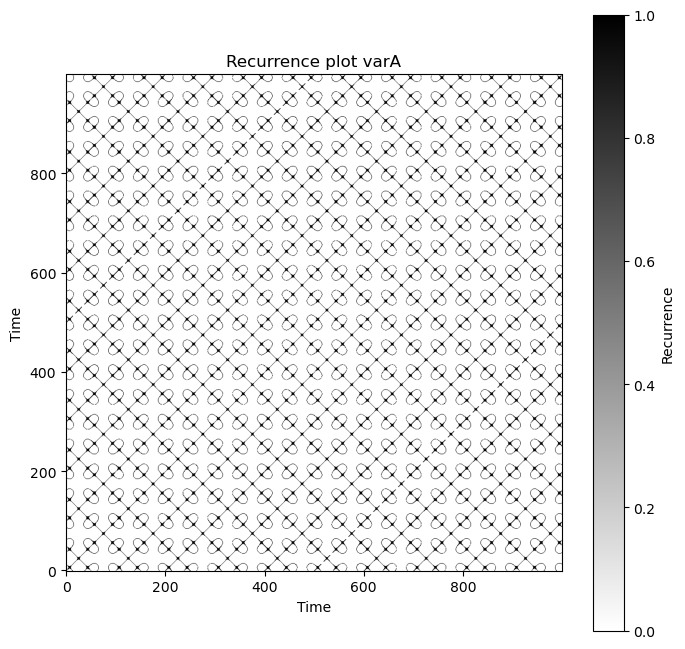

In [42]:
recA = recurrence_plot(varA, threshold=0.05)

plt.figure(figsize=(8, 8))
plt.imshow(recA, cmap='binary', origin='lower')
plt.title('Recurrence plot varA')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

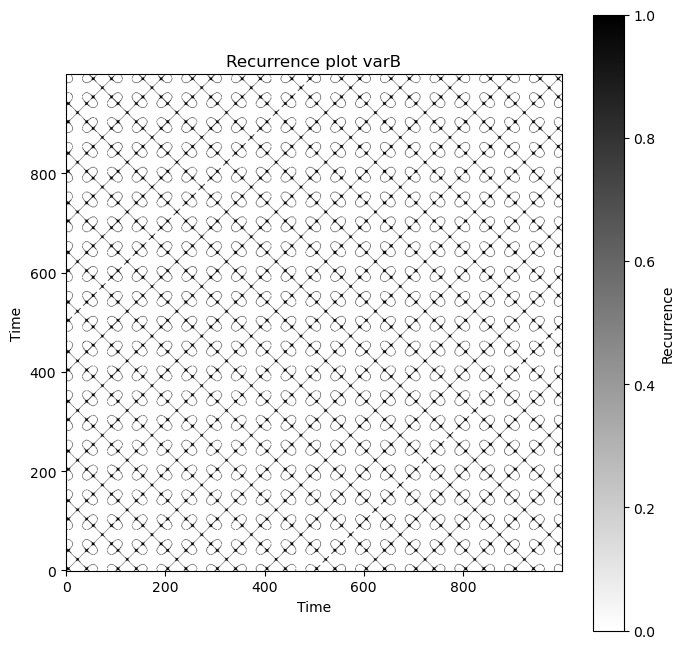

In [43]:
recB = recurrence_plot(varB, threshold=0.05)

plt.figure(figsize=(8, 8))
plt.imshow(recB, cmap='binary', origin='lower')
plt.title('Recurrence plot varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

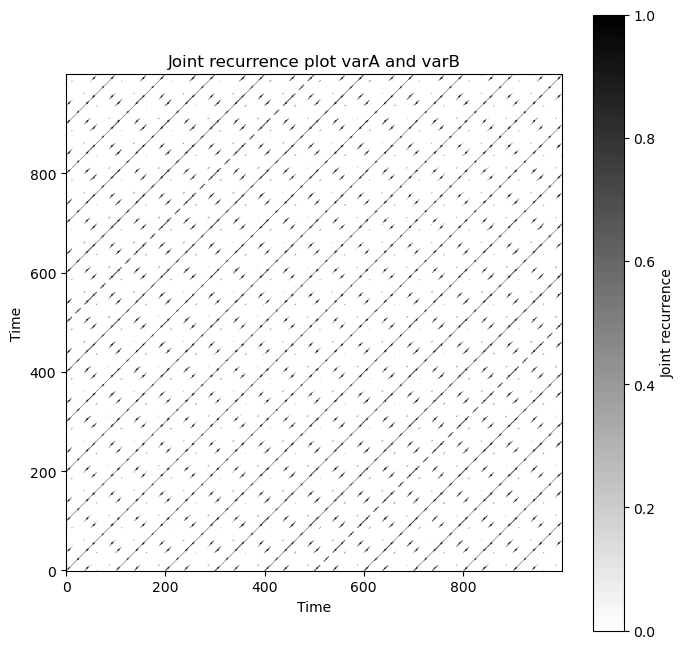

In [44]:
joint_rec = recA*recB

plt.figure(figsize=(8, 8))
plt.imshow(joint_rec, cmap='binary', origin='lower')
plt.title('Joint recurrence plot varA and varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Joint recurrence')
plt.show